# VoxBind - Docking Metric Plots

Loads the cached `metrics.json` files - the same data source as
`00_dashboard.ipynb` - and plots the docking (AutoDock Vina) metrics.

### How to use
1. Run **section 0 (Setup)** once. It reuses the dashboard's loader and
   discovers every experiment / run under
   `voxbind/exps/<experiment>/samples/<run>/target_*/`.
2. **Section 1** prints one row per `(experiment, run)`; note the `idx` of
   the runs you want to plot.
3. In **section 2**, set `SELECTED_RUNS` to those `idx` values (or leave it
   `None` for all runs) and run the cell to draw the box plots.

### Notes
- Like the dashboard, this notebook only *reads* pre-computed `metrics.json`;
  refresh those files with the Streamlit app (`notebook/webapp/app.py`).
- Vina energies are in kcal/mol and **lower is better** for every variant
  (`score_only`, `minimize`, `dock`).
- Each box pools every generated molecule across all of a run's targets; the
  hatched grey box beside it is that run's reference ligands.
- Runs with no docking metrics computed are skipped and flagged in section 2.

In [10]:
# Section 0 - Setup: helper functions (run once).
import json
import math
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 260)
pd.set_option("display.max_colwidth", 100)


def show(obj, round_to=3):
    """Render a DataFrame/Series in Jupyter, falling back to plain text."""
    if isinstance(obj, (pd.DataFrame, pd.Series)):
        obj = obj.round(round_to)
    try:
        from IPython.display import display
        display(obj)
    except Exception:
        print(obj)


# -- locate the repository ---------------------------------------------------
def find_repo_root() -> Path:
    """Walk up from the working directory until voxbind/exps/ is found."""
    for cand in [Path.cwd(), *Path.cwd().parents]:
        if (cand / "voxbind" / "exps").is_dir():
            return cand
    fallback = Path("/home/shpark/prj-denovo/VoxBind")
    if (fallback / "voxbind" / "exps").is_dir():
        return fallback
    raise FileNotFoundError("Could not find voxbind/exps/ - run from inside the repo.")


REPO = find_repo_root()
EXPS_ROOT = REPO / "voxbind" / "exps"
METRICS_VERSION = 2          # version stamp written by notebook/webapp/metrics.py
print(f"repo      : {REPO}")
print(f"exps root : {EXPS_ROOT}")


# -- experiment / run / target discovery -------------------------------------
def list_runs(exp_dir: Path) -> list:
    """Sampling-run subdirs under <exp>/samples/ that hold target_* folders."""
    samples = exp_dir / "samples"
    if not samples.is_dir():
        return []
    return sorted(d.name for d in samples.iterdir()
                  if d.is_dir() and any(d.glob("target_*")))


def list_experiments() -> list:
    """Experiment names with at least one non-empty sampling run."""
    if not EXPS_ROOT.is_dir():
        return []
    return sorted(p.name for p in EXPS_ROOT.iterdir()
                  if p.is_dir() and list_runs(p))


def list_targets(exp_name: str, run: str) -> list:
    """Sorted target_* directories for one (experiment, run)."""
    run_dir = EXPS_ROOT / exp_name / "samples" / run
    if not run_dir.is_dir():
        return []
    return sorted(t for t in run_dir.glob("target_*") if t.is_dir())


# -- metrics.json loading and freshness --------------------------------------
def metrics_status(target_dir: Path) -> str:
    """One of: fresh | stale | no-metrics | no-samples."""
    mp = target_dir / "metrics.json"
    sdf = target_dir / "samples.sdf"
    if not sdf.exists():
        return "no-samples"
    if not mp.exists():
        return "no-metrics"
    try:
        data = json.loads(mp.read_text())
    except (json.JSONDecodeError, OSError):
        return "no-metrics"
    if data.get("version") != METRICS_VERSION:
        return "stale"
    return "fresh" if mp.stat().st_mtime >= sdf.stat().st_mtime else "stale"


def load_metrics(target_dir: Path):
    """Parsed metrics.json dict, or None if absent / unreadable."""
    mp = target_dir / "metrics.json"
    if not mp.exists():
        return None
    try:
        return json.loads(mp.read_text())
    except (json.JSONDecodeError, OSError):
        return None


# -- docking metrics (Vina) - optional, may not be computed yet --------------
# Per-sample docking is expected either as a nested {"vina": {...}} dict
# (poc_evaluate.py convention) or as flat vina_* keys. When nothing is found,
# the vina_* columns stay NaN and the dashboard flags the target/experiment.
VINA_COLS = ["vina_score", "vina_min", "vina_dock"]
_VINA_NESTED = {"score_only": "vina_score", "minimize": "vina_min", "dock": "vina_dock"}


def sample_docking(sample: dict) -> dict:
    """Extract {vina_score, vina_min, vina_dock} from one sample record."""
    out = {}
    v = sample.get("vina")
    if isinstance(v, dict) and "error" not in v:
        for src, dst in _VINA_NESTED.items():
            if isinstance(v.get(src), (int, float)):
                out[dst] = float(v[src])
    for col in VINA_COLS:
        if isinstance(sample.get(col), (int, float)):
            out[col] = float(sample[col])
    return out


def target_docking(metrics: dict) -> dict:
    """Mean Vina metrics for a target - NaN for any not computed."""
    out = {c: float("nan") for c in VINA_COLS}
    acc = {c: [] for c in VINA_COLS}
    for s in metrics.get("samples", []):
        for c, val in sample_docking(s).items():
            acc[c].append(val)
    for c in VINA_COLS:
        if acc[c]:
            out[c] = float(np.mean(acc[c]))
    # fall back to aggregate-level keys, in case a future pipeline writes them there
    agg = metrics.get("aggregates", {})
    aliases = {
        "vina_score": ("vina_score_mean", "vina_score", "Vina score mean"),
        "vina_min":   ("vina_min_mean", "vina_min", "Vina min mean"),
        "vina_dock":  ("vina_dock_mean", "vina_dock", "Vina dock mean"),
    }
    for c, names in aliases.items():
        if math.isnan(out[c]):
            for n in names:
                if isinstance(agg.get(n), (int, float)):
                    out[c] = float(agg[n])
                    break
    return out


def has_docking(metrics) -> bool:
    """True if any Vina metric is present in this target's metrics."""
    return metrics is not None and any(
        not math.isnan(v) for v in target_docking(metrics).values()
    )


print("setup ready: list_experiments, list_runs, list_targets, load_metrics,")
print("             metrics_status, has_docking, sample_docking")


def experiment_run_table() -> pd.DataFrame:
    """Discover every (experiment, run) pair and summarise its coverage."""
    rows = []
    for exp_name in list_experiments():
        for run in list_runs(EXPS_ROOT / exp_name):
            targets = list_targets(exp_name, run)
            n_fresh = n_dock = n_samples = 0
            for tdir in targets:
                if metrics_status(tdir) == "fresh":
                    n_fresh += 1
                m = load_metrics(tdir)
                if has_docking(m):
                    n_dock += 1
                if m is not None:
                    n_samples += len(m.get("samples", []))
            rows.append({
                "experiment": exp_name,
                "run": run,
                "targets": len(targets),
                "evaluated": f"{n_fresh}/{len(targets)}",
                "docking": f"{n_dock}/{len(targets)}" if n_dock else "none",
                "samples": n_samples,
            })
    df = pd.DataFrame(rows)
    df.index.name = "idx"
    return df


RUN_TABLE = experiment_run_table()
if RUN_TABLE.empty:
    print(f"No experiments with generated samples under {EXPS_ROOT}")
else:
    print(f"{len(RUN_TABLE)} (experiment, run) pair(s) - idx is the plot selector:")
    show(RUN_TABLE)

repo      : /home/shpark/prj-denovo/VoxBind
exps root : /home/shpark/prj-denovo/VoxBind/voxbind/exps
setup ready: list_experiments, list_runs, list_targets, load_metrics,
             metrics_status, has_docking, sample_docking
12 (experiment, run) pair(s) - idx is the plot selector:


,experiment,run,targets,evaluated,docking,samples
idx,,,,,,
0,260514_voxbind_100ep_original,res_ep7999_test10,10,10/10,10/10,100
1,260514_voxbind_100ep_original,res_ep7999_val,10,10/10,10/10,100
2,260515_voxbind_100ep_density,res_ep7999_test10,10,10/10,10/10,99
3,260515_voxbind_100ep_density,res_ep7999_val,10,10/10,10/10,98
4,260516_voxbind_100ep_noise,res_ep7999_test10,10,10/10,10/10,100
5,260516_voxbind_100ep_noise,res_ep7999_val,10,10/10,9/10,100
6,260518_voxbind_10k_baseline,res_ep99_test,92,10/92,10/92,99
7,260518_voxbind_10k_density,res_ep99_test,66,65/66,65/66,649
8,260518_voxbind_10k_noise,res_ep99_test,63,62/63,62/63,618


## Docking metric box plots

Per-sample Vina distributions for the selected runs - one stacked panel per
variant (`score_only`, `minimize`, `dock`). Each `(experiment, run)` is one
box pooling every generated molecule across all of the run's targets; the
white diamond marks the mean. Lower Vina energy is better.

Runs are grouped by **sampling type** (the run name): same-type runs were
sampled on the same pockets and so share the same reference ligands. Each
group puts **one** hatched grey reference box at its left, a vertical
divider, then the run boxes; a dashed line at the reference median lets every
box read against that baseline.

Extreme outliers (fliers) are hidden so the boxes stay legible; the mean
diamond and the summary table below still account for them.

Set `SELECTED_RUNS` to a list of `idx` values from the table above (or
`(experiment, run)` tuples); leave it `None` to plot every run.

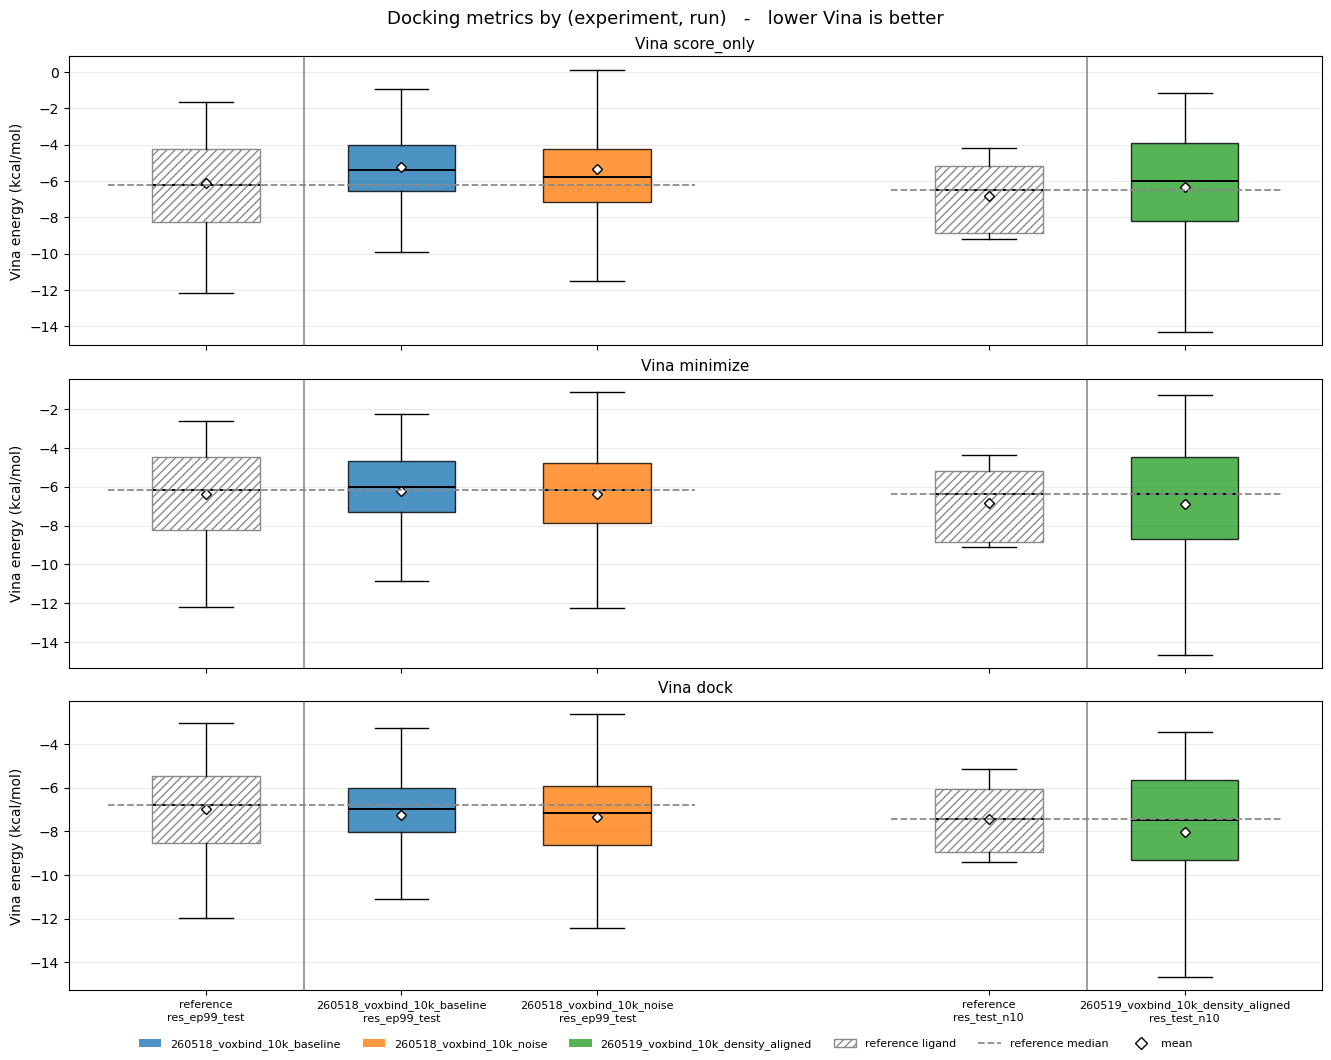

mean Vina energy (kcal/mol) - generated vs reference ligand ('/ref'):


,,score_only,score_only/ref,minimize,minimize/ref,dock,dock/ref,n
experiment,run,,,,,,,
260518_voxbind_10k_baseline,res_ep99_test,-5.237,-6.713,-6.233,-6.910,-7.248,-7.374,99
260518_voxbind_10k_noise,res_ep99_test,-5.333,-5.991,-6.358,-6.285,-7.363,-6.926,618
260519_voxbind_10k_density_aligned,res_test_n10,-6.319,-6.852,-6.902,-6.851,-8.026,-7.440,70


In [11]:
# Section 1 - docking (Vina) box plots for the selected runs.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ======================================================================
#  vvv  SELECT RUNS TO PLOT  vvv
#  idx values from the table above, (experiment, run) tuples, or None for all.
# SELECTED_RUNS = [0, 2, 4]
SELECTED_RUNS = [6, 8, 9]
# ======================================================================

VINA_PANELS = [
    ("vina_score", "score_only"),
    ("vina_min",   "minimize"),
    ("vina_dock",  "dock"),
]


def run_vina_distributions(exp_name: str, run: str) -> dict:
    """Pooled Vina values for one run.

    Returns {"gen": {col: [values]}, "ref": {col: [values]}} where col is one
    of VINA_COLS. "gen" pools every generated sample across all targets;
    "ref" holds one reference-ligand value per target.
    """
    gen = {c: [] for c in VINA_COLS}
    ref = {c: [] for c in VINA_COLS}
    for tdir in list_targets(exp_name, run):
        m = load_metrics(tdir)
        if m is None:
            continue
        for s in m.get("samples", []):
            for c, val in sample_docking(s).items():
                gen[c].append(val)
        rv = (m.get("reference") or {}).get("vina")
        if isinstance(rv, dict) and "error" not in rv:
            for src, dst in _VINA_NESTED.items():
                if isinstance(rv.get(src), (int, float)):
                    ref[dst].append(float(rv[src]))
    return {"gen": gen, "ref": ref}


# -- resolve SELECTED_RUNS into a list of (experiment, run) ------------------
all_runs = list(RUN_TABLE[["experiment", "run"]].itertuples(index=False, name=None))
if SELECTED_RUNS is None:
    chosen = list(all_runs)
else:
    chosen = []
    for item in SELECTED_RUNS:
        if isinstance(item, int):
            chosen.append(all_runs[item])
        elif tuple(item) in all_runs:
            chosen.append(tuple(item))
        else:
            raise ValueError(f"{item!r} is not a valid idx or (experiment, run); "
                             f"choose from {all_runs}")

# -- gather distributions, keeping only runs that have docking metrics -------
plot_runs, data = [], {}
for exp_name, run in chosen:
    d = run_vina_distributions(exp_name, run)
    if any(d["gen"][c] for c in VINA_COLS):
        plot_runs.append((exp_name, run))
        data[(exp_name, run)] = d
    else:
        print(f"  skip {exp_name} / {run}: no docking metrics computed")

if not plot_runs:
    print("Nothing to plot - none of the selected runs have docking metrics.")
else:
    # -- group runs by sampling type ----------------------------------------
    # Runs sharing a sampling type (the run name) were sampled on the same
    # pockets, so they share the same reference ligands. Each group therefore
    # draws ONE reference box at its left plus a dashed reference-median line,
    # rather than repeating the reference next to every run.
    groups = []                       # [(run_name, [(exp, run), ...]), ...]
    _group_of = {}
    for key in plot_runs:
        rn = key[1]
        if rn not in _group_of:
            _group_of[rn] = len(groups)
            groups.append((rn, []))
        groups[_group_of[rn]][1].append(key)

    # -- lay out x slots: [reference] [run] [run] ... for each group --------
    GAP = 1.0                         # blank slot between sampling-type groups
    ref_x, run_x, span = {}, {}, {}   # run_name->x, (exp,run)->x, run_name->(lo,hi)
    xticks, xticklabels = [], []
    x = 0.0
    for rn, keys in groups:
        has_ref = any(data[k]["ref"][c] for k in keys for c in VINA_COLS)
        lo = x
        if has_ref:
            ref_x[rn] = x
            xticks.append(x)
            xticklabels.append(f"reference\n{rn}")
            x += 1.0
        else:
            ref_x[rn] = None
        for k in keys:
            run_x[k] = x
            xticks.append(x)
            xticklabels.append(f"{k[0]}\n{k[1]}")
            x += 1.0
        span[rn] = (lo, x - 1.0)
        x += GAP
    any_ref = any(v is not None for v in ref_x.values())

    # -- styling ------------------------------------------------------------
    exps = list(dict.fromkeys(e for e, _ in plot_runs))
    palette = plt.get_cmap("tab10")
    exp_color = {e: palette(i % 10) for i, e in enumerate(exps)}
    REF_COLOR = "#8a8a8a"
    mean_props = dict(marker="D", markerfacecolor="white",
                      markeredgecolor="black", markersize=5)
    median_props = dict(color="black", linewidth=1.4)

    # one stacked panel per Vina variant; fliers hidden so a few garbage
    # poses do not compress the y-axis.
    fig_w = max(12.0, 2.2 * (max(xticks) + 1))
    fig, axes = plt.subplots(3, 1, figsize=(fig_w, 10.5),
                             sharex=True, layout="constrained")

    for ax, (col, label) in zip(axes, VINA_PANELS):
        ax.set_axisbelow(True)
        gen_d, gen_pos, gen_exp = [], [], []
        ref_d, ref_pos = [], []
        for rn, keys in groups:
            # vertical divider: reference (left) | experiment results (right)
            if ref_x[rn] is not None:
                ax.axvline(ref_x[rn] + 0.5, color="0.55", linewidth=1.2,
                           zorder=1)
            ref_pooled = [v for k in keys for v in data[k]["ref"][col]]
            if ref_x[rn] is not None and ref_pooled:
                ref_d.append(ref_pooled)
                ref_pos.append(ref_x[rn])
                lo, hi = span[rn]
                med = float(np.median(ref_pooled))
                ax.plot([lo - 0.5, hi + 0.5], [med, med], color=REF_COLOR,
                        linestyle="--", linewidth=1.3, zorder=4)
            for k in keys:
                g = data[k]["gen"][col]
                if g:
                    gen_d.append(g)
                    gen_pos.append(run_x[k])
                    gen_exp.append(k[0])
        if gen_d:
            bp = ax.boxplot(gen_d, positions=gen_pos, widths=0.55,
                            patch_artist=True, showmeans=True, showfliers=False,
                            meanprops=mean_props, medianprops=median_props)
            for box, e in zip(bp["boxes"], gen_exp):
                box.set_facecolor(exp_color[e])
                box.set_alpha(0.80)
        if ref_d:
            rp = ax.boxplot(ref_d, positions=ref_pos, widths=0.55,
                            patch_artist=True, showmeans=True, showfliers=False,
                            meanprops=mean_props, medianprops=median_props)
            for box in rp["boxes"]:
                box.set_facecolor("white")
                box.set_edgecolor(REF_COLOR)
                box.set_hatch("////")
        ax.set_title(f"Vina {label}", fontsize=11)
        ax.set_ylabel("Vina energy (kcal/mol)")
        ax.grid(axis="y", alpha=0.30, linewidth=0.6)

    # shared x-axis: reference + run ticks, two-line labels
    axes[-1].set_xticks(xticks)
    axes[-1].set_xticklabels(xticklabels, fontsize=8)
    axes[-1].set_xlim(min(xticks) - 0.7, max(xticks) + 0.7)

    handles = [mpatches.Patch(facecolor=exp_color[e], alpha=0.80, label=e)
               for e in exps]
    if any_ref:
        handles.append(mpatches.Patch(facecolor="white", edgecolor=REF_COLOR,
                                      hatch="////", label="reference ligand"))
        handles.append(Line2D([], [], color=REF_COLOR, linestyle="--",
                              linewidth=1.3, label="reference median"))
    handles.append(Line2D([], [], marker="D", linestyle="none",
                          markerfacecolor="white", markeredgecolor="black",
                          markersize=6, label="mean"))
    fig.legend(handles=handles, loc="outside lower center",
               ncol=min(len(handles), 6), fontsize=8, frameon=False)
    fig.suptitle("Docking metrics by (experiment, run)   -   "
                 "lower Vina is better", fontsize=13)
    plt.show()

    # -- numeric summary behind the plot ------------------------------------
    summary_rows = []
    for exp_name, run in plot_runs:
        d = data[(exp_name, run)]
        srow = {"experiment": exp_name, "run": run}
        for col, label in VINA_PANELS:
            g, r = d["gen"][col], d["ref"][col]
            srow[label] = float(np.mean(g)) if g else float("nan")
            srow[f"{label}/ref"] = float(np.mean(r)) if r else float("nan")
        srow["n"] = max(len(d["gen"][c]) for c in VINA_COLS)
        summary_rows.append(srow)
    summary = pd.DataFrame(summary_rows).set_index(["experiment", "run"])
    print("mean Vina energy (kcal/mol) - generated vs reference ligand ('/ref'):")
    show(summary)